In [188]:
import pandas as pd
import numpy as np
from pathlib import Path




import matplotlib.pyplot as plt
import seaborn as sns



from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import GridSearchCV



In [126]:


PROJECT_ROOT = Path.cwd().parent
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
DATASET_PATH = RAW_DATA_DIR / "kitchen_ml_dataset.xlsx"


def load_excel_dataset(file_path: Path) -> pd.DataFrame:
    """Load the kitchen dataset from an Excel file."""
    if not file_path.exists():
        raise FileNotFoundError(f"Dataset not found: {file_path}")

    return pd.read_excel(file_path)


df = load_excel_dataset(DATASET_PATH)

print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()


Dataset shape: 730 rows, 15 columns


,date,day_of_week,weekend,holiday,service_type,total_customers,total_orders,total_revenue,avg_order_value,num_chefs,num_waiters,num_items_sold,weather,temperature,special_event
0,2025-05-01,Thursday,y,y,brunch,78,79,1197.11,15.35,2,3,79,unknown,0,1
1,2025-05-01,Thursday,no,NaN,DINNER,125,120,2206.52,17.65,3,4,120,cloudy,23C,Y
2,2025-05-02,Friday,n,true,night,42,42,950.75,22.64,2,2,126,rainy,15C,Y
3,2025-05-02,Friday,NO,y,DINNER,55,55,1107.99,20.15,2,2,165,NaN,16C,1
4,2025-05-03,Saturday,y,n,night,116,120,2473.44,21.32,3,4,240,SUN,10C,0


In [127]:
df.columns 

Index(['date', 'day_of_week', 'weekend', 'holiday', 'service_type',
       'total_customers', 'total_orders', 'total_revenue', 'avg_order_value',
       'num_chefs', 'num_waiters', 'num_items_sold', 'weather', 'temperature',
       'special_event'],
      dtype='str')

In [128]:
def inspect_dataset_structure(data: pd.DataFrame) -> pd.DataFrame:
    """Return a summary of column types, missing values, and unique values."""
    summary = pd.DataFrame(
        {
            "data_type": data.dtypes,
            "missing_values": data.isna().sum(),
            "missing_percentage": (data.isna().mean() * 100).round(2),
            "unique_values": data.nunique(),
        }
    )

    return summary


structure_summary = inspect_dataset_structure(df)
structure_summary


,data_type,missing_values,missing_percentage,unique_values
date,str,0,0.00,365
day_of_week,str,0,0.00,7
weekend,str,0,0.00,8
holiday,str,101,13.84,8
service_type,str,0,0.00,6
total_customers,int64,0,0.00,164
total_orders,int64,0,0.00,171
total_revenue,float64,0,0.00,728
avg_order_value,float64,0,0.00,517
num_chefs,int64,0,0.00,4


In [129]:
def show_unique_values(data: pd.DataFrame, columns: list[str]) -> None:
    """Print unique values for selected columns."""
    for column in columns:
        print(f"\n{column}")
        print("-" * len(column))
        print(data[column].dropna().unique())


categorical_columns = [
    "day_of_week",
    "weekend",
    "holiday",
    "service_type",
    "weather",
    "temperature",
    "special_event",
]

show_unique_values(df, categorical_columns)



day_of_week
-----------
<StringArray>
['Thursday', 'Friday', 'Saturday', 'Sunday', 'Monday', 'Tuesday', 'Wednesday']
Length: 7, dtype: str

weekend
-------
<StringArray>
['y', 'no', 'n', 'NO', 'yes', 'Yes', 'false', 'true']
Length: 8, dtype: str

holiday
-------
<StringArray>
['y', 'true', 'n', 'false', 'no', 'yes', 'NO', 'Yes']
Length: 8, dtype: str

service_type
------------
<StringArray>
['brunch', 'DINNER', 'night', 'dinner', 'Lunch ', 'lunch']
Length: 6, dtype: str

weather
-------
<StringArray>
['unknown', 'cloudy', 'rainy', 'SUN', 'stormy', 'snowy', 'sunny', 'Rain']
Length: 8, dtype: str

temperature
-----------
[0 '23C' '15C' '16C' '10C' '--' 13 'cold' 'hot' 23 '18C' '13C' '11C' 7
 '25C' 26 '14C' '30C' '29C' 11 '24C' '12C' '26C' '19C' 22 '22C' 20 '17C'
 '28C' '21C' 18 14 -2 24 25 16 19 21 -4 8 27 -3 10 -5 3 17 30 5 '27C' 9 29
 -1 12 28 1 4 '20C' 2 15 6]

special_event
-------------
<StringArray>
['1', 'Y', '0', 'holiday?', 'yes', 'no', 'N']
Length: 7, dtype: str


In [130]:
def summarize_numeric_columns(data: pd.DataFrame) -> pd.DataFrame:
    """Return descriptive statistics for numeric columns."""
    numeric_data = data.select_dtypes(include=["number"])

    return numeric_data.describe().T


numeric_summary = summarize_numeric_columns(df)
numeric_summary


,count,mean,std,min,25%,50%,75%,max
total_customers,730.0,85.939726,42.435319,21.00,54.0000,76.000,105.0000,247.00
total_orders,730.0,85.968493,42.672876,18.00,54.2500,76.000,105.0000,251.00
total_revenue,730.0,1714.306589,899.338962,380.69,1068.5925,1492.875,2115.3125,5920.81
avg_order_value,730.0,19.921630,2.863761,15.02,17.5225,20.035,22.3875,24.99
num_chefs,730.0,2.389041,0.696368,2.00,2.0000,2.000,3.0000,5.00
num_waiters,730.0,2.991781,1.175861,2.00,2.0000,3.000,3.0000,8.00
num_items_sold,730.0,173.528767,116.105422,18.00,86.0000,145.000,234.0000,723.00


In [131]:
# Now we should inspect relationships between the numeric columns. And see which variables are moving together.
# This will help us to avoid the data leakage 


def calculate_numeric_correlations(data: pd.DataFrame) -> pd.DataFrame:
    """Return correlations between numeric columns."""
    numeric_data = data.select_dtypes(include=["number"])

    return numeric_data.corr().round(3)


correlation_matrix = calculate_numeric_correlations(df)
correlation_matrix


,total_customers,total_orders,total_revenue,avg_order_value,num_chefs,num_waiters,num_items_sold
total_customers,1.000,0.997,0.955,0.019,0.904,0.965,0.741
total_orders,0.997,1.000,0.953,0.020,0.899,0.963,0.741
total_revenue,0.955,0.953,1.000,0.287,0.866,0.920,0.699
avg_order_value,0.019,0.020,0.287,1.000,0.026,0.004,-0.006
num_chefs,0.904,0.899,0.866,0.026,1.000,0.902,0.664
num_waiters,0.965,0.963,0.920,0.004,0.902,1.000,0.709
num_items_sold,0.741,0.741,0.699,-0.006,0.664,0.709,1.000


----

## Target selection

### From my own experience as a chef I know that the biggest challenge is the 'staff planning' and I know that  :

The first machine learning target for this project is `num_items_sold`.

This target is useful for kitchen planning because it can help estimate daily food preparation demand. To keep the model realistic, the first version will only use features that are likely to be known before service starts, such as date information, service type, weather, temperature, holidays, weekends, and special events.

Columns such as `total_customers`, `total_orders`, `total_revenue`, `avg_order_value`, `num_chefs`, and `num_waiters` are excluded from the first model because they may not be known before the day happens or may create data leakage.


## The model is useful for:

### -kitchen workload
### -expected demand
### -planning food preparation
### -planning staff


---

In [132]:
TARGET_COLUMN = "total_orders"

FEATURE_COLUMNS = [
    "date",
    "day_of_week",
    "weekend",
    "holiday",
    "service_type",
    "weather",
    "temperature",
    "special_event",
]

EXCLUDED_COLUMNS = [
    "total_customers",
    "total_revenue",
    "avg_order_value",
    "num_chefs",
    "num_waiters",
    "num_items_sold",
]


def validate_model_columns(
    data: pd.DataFrame,
    target_column: str,
    feature_columns: list[str],
    excluded_columns: list[str],
) -> None:
    """Validate that model columns exist and do not overlap incorrectly."""
    required_columns = [target_column] + feature_columns + excluded_columns
    missing_columns = [column for column in required_columns if column not in data.columns]

    if missing_columns:
        raise ValueError(f"Missing columns in dataset: {missing_columns}")

    if target_column in feature_columns:
        raise ValueError("Target column cannot also be a feature column.")

    overlapping_columns = set(feature_columns).intersection(excluded_columns)
    if overlapping_columns:
        raise ValueError(f"Columns cannot be both features and excluded: {overlapping_columns}")

    print("Model columns validated successfully.")
    print(f"Target column: {target_column}")
    print(f"Number of feature columns: {len(feature_columns)}")
    print(f"Number of excluded columns: {len(excluded_columns)}")


validate_model_columns(
    data=df,
    target_column=TARGET_COLUMN,
    feature_columns=FEATURE_COLUMNS,
    excluded_columns=EXCLUDED_COLUMNS,
)


Model columns validated successfully.
Target column: total_orders
Number of feature columns: 8
Number of excluded columns: 6


In [133]:
def create_modeling_dataset(
    data: pd.DataFrame,
    feature_columns: list[str],
    target_column: str,
) -> pd.DataFrame:
    """Create a modeling dataset with only selected features and target."""
    selected_columns = feature_columns + [target_column]

    return data[selected_columns].copy()


model_df = create_modeling_dataset(
    data=df,
    feature_columns=FEATURE_COLUMNS,
    target_column=TARGET_COLUMN,
)

print(f"Modeling dataset shape: {model_df.shape[0]} rows, {model_df.shape[1]} columns")
model_df.head()


Modeling dataset shape: 730 rows, 9 columns


,date,day_of_week,weekend,holiday,service_type,weather,temperature,special_event,total_orders
0,2025-05-01,Thursday,y,y,brunch,unknown,0,1,79
1,2025-05-01,Thursday,no,NaN,DINNER,cloudy,23C,Y,120
2,2025-05-02,Friday,n,true,night,rainy,15C,Y,42
3,2025-05-02,Friday,NO,y,DINNER,NaN,16C,1,55
4,2025-05-03,Saturday,y,n,night,SUN,10C,0,120


In [134]:
def clean_text_value(value: object) -> object:
    """Clean a single text-like value by lowercasing and stripping spaces."""
    if pd.isna(value):
        return value

    return str(value).strip().lower()


def standardize_binary_value(value: object) -> object:
    """Convert common yes/no style values into 1, 0, or missing."""
    cleaned_value = clean_text_value(value)

    if pd.isna(cleaned_value):
        return pd.NA

    positive_values = {"y", "yes", "true", "1"}
    negative_values = {"n", "no", "false", "0"}

    if cleaned_value in positive_values:
        return 1

    if cleaned_value in negative_values:
        return 0

    return pd.NA


def standardize_binary_columns(data: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    """Standardize selected binary columns to 1, 0, or missing."""
    cleaned_data = data.copy()

    for column in columns:
        cleaned_data[column] = cleaned_data[column].apply(standardize_binary_value).astype("Int64")

    return cleaned_data


binary_columns = ["weekend", "holiday", "special_event"]

cleaned_model_df = standardize_binary_columns(
    data=model_df,
    columns=binary_columns,
)

cleaned_model_df[binary_columns].head()


,weekend,holiday,special_event
0,1,1,1
1,0,<NA>,1
2,0,1,1
3,0,1,1
4,1,0,0


In [135]:
def summarize_binary_columns(data: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    """Summarize value counts for binary columns after cleaning."""
    summaries = []

    for column in columns:
        value_counts = data[column].value_counts(dropna=False).to_dict()

        summaries.append(
            {
                "column": column,
                "count_0": value_counts.get(0, 0),
                "count_1": value_counts.get(1, 0),
                "missing_count": value_counts.get(pd.NA, 0),
            }
        )

    return pd.DataFrame(summaries)


binary_summary = summarize_binary_columns(
    data=cleaned_model_df,
    columns=binary_columns,
)

binary_summary


,column,count_0,count_1,missing_count
0,weekend,362,368,0
1,holiday,315,314,101
2,special_event,265,265,200


In [ ]:
# This cleans the categorical text columns we will use in the model. 
# #It standardizes casing/spaces and merges duplicated weather labels, 
# which avoids treating DINNER and dinner as different categories later.




def standardize_text_columns(data: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    """Standardize text columns by stripping spaces and converting to lowercase."""
    cleaned_data = data.copy()

    for column in columns:
        cleaned_data[column] = cleaned_data[column].apply(clean_text_value).astype("string")

    return cleaned_data


def normalize_weather_value(value: object) -> object:
    """Normalize weather labels into consistent categories."""
    cleaned_value = clean_text_value(value)

    if pd.isna(cleaned_value):
        return pd.NA

    weather_mapping = {
        "sun": "sunny",
        "rain": "rainy",
        "unknown": pd.NA,
    }

    return weather_mapping.get(cleaned_value, cleaned_value)


text_columns = ["day_of_week", "service_type"]

cleaned_model_df = standardize_text_columns(
    data=cleaned_model_df,
    columns=text_columns,
)

cleaned_model_df["weather"] = cleaned_model_df["weather"].apply(normalize_weather_value).astype("string")

cleaned_model_df[["day_of_week", "service_type", "weather"]].head()


,day_of_week,service_type,weather
0,thursday,brunch,<NA>
1,thursday,dinner,cloudy
2,friday,night,rainy
3,friday,dinner,<NA>
4,saturday,night,sunny


In [137]:
def summarize_category_values(data: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    """Summarize category values after cleaning."""
    summaries = []

    for column in columns:
        summaries.append(
            {
                "column": column,
                "unique_count": data[column].nunique(dropna=True),
                "missing_count": data[column].isna().sum(),
                "unique_values": sorted(data[column].dropna().unique().tolist()),
            }
        )

    return pd.DataFrame(summaries)


category_columns = ["day_of_week", "service_type", "weather"]

category_summary = summarize_category_values(
    data=cleaned_model_df,
    columns=category_columns,
)

category_summary


,column,unique_count,missing_count,unique_values
0,day_of_week,7,0,"[friday, monday, saturday, sunday, thursday, t..."
1,service_type,4,0,"[brunch, dinner, lunch, night]"
2,weather,5,187,"[cloudy, rainy, snowy, stormy, sunny]"


In [138]:
def clean_temperature_value(value: object) -> object:
    """Convert temperature values like '23C' or 23 into numeric values."""
    if pd.isna(value):
        return pd.NA

    cleaned_value = str(value).strip().lower()

    invalid_values = {"--", "cold", "hot", ""}

    if cleaned_value in invalid_values:
        return pd.NA

    cleaned_value = cleaned_value.replace("c", "")

    try:
        return float(cleaned_value)
    except ValueError:
        return pd.NA


def clean_temperature_column(data: pd.DataFrame, column: str) -> pd.DataFrame:
    """Clean a temperature column and convert it to numeric."""
    cleaned_data = data.copy()
    cleaned_data[column] = cleaned_data[column].apply(clean_temperature_value).astype("Float64")

    return cleaned_data


cleaned_model_df = clean_temperature_column(
    data=cleaned_model_df,
    column="temperature",
)

cleaned_model_df[["temperature"]].head()


,temperature
0,0.0
1,23.0
2,15.0
3,16.0
4,10.0


---

## After cleaning, temperature has 497 missing values, which is 68.08% of the column.

## That is a lot.

### We will come back to this and look closer at it 

In [139]:
def summarize_temperature_column(data: pd.DataFrame, column: str) -> pd.DataFrame:
    """Summarize a cleaned numeric temperature column."""
    return pd.DataFrame(
        {
            "data_type": [data[column].dtype],
            "missing_count": [data[column].isna().sum()],
            "missing_percentage": [(data[column].isna().mean() * 100).round(2)],
            "min": [data[column].min()],
            "mean": [data[column].mean().round(2)],
            "median": [data[column].median()],
            "max": [data[column].max()],
        }
    )


temperature_summary = summarize_temperature_column(
    data=cleaned_model_df,
    column="temperature",
)

temperature_summary


,data_type,missing_count,missing_percentage,min,mean,median,max
0,Float64,497,68.08,-5.0,17.42,19.0,30.0


---

### We can see that th original weekend column is inconsistent , day_of_week is cleaner and has 7 valid values.
### A derived is_weekend feature is more reliable than the messy original weekend.

In [168]:
def add_time_features(
    data: pd.DataFrame,
    date_column: str,
    day_column: str,
) -> pd.DataFrame:
    """Create date-based and calendar-based features."""
    cleaned_data = data.copy()

    cleaned_data[date_column] = pd.to_datetime(cleaned_data[date_column], errors="coerce")

    cleaned_data["year"] = cleaned_data[date_column].dt.year
    cleaned_data["month"] = cleaned_data[date_column].dt.month
    cleaned_data["day"] = cleaned_data[date_column].dt.day
    cleaned_data["day_of_year"] = cleaned_data[date_column].dt.dayofyear

    weekend_days = {"saturday", "sunday"}
    cleaned_data["is_weekend"] = cleaned_data[day_column].isin(weekend_days).astype(int)

    return cleaned_data


cleaned_model_df = add_time_features(
    data=cleaned_model_df,
    date_column="date",
    day_column="day_of_week",
)

cleaned_model_df[["date", "day_of_week", "is_weekend", "year", "month", "day", "day_of_year"]].head()


,date,day_of_week,is_weekend,year,month,day,day_of_year
0,2025-05-01,thursday,0,2025,5,1,121
1,2025-05-01,thursday,0,2025,5,1,121
2,2025-05-02,friday,0,2025,5,2,122
3,2025-05-02,friday,0,2025,5,2,122
4,2025-05-03,saturday,1,2025,5,3,123


---

## Now let's take a look at tghe data-set after cleaning

In [169]:
cleaned_structure_summary = inspect_dataset_structure(cleaned_model_df)
cleaned_structure_summary


,data_type,missing_values,missing_percentage,unique_values
date,datetime64[us],0,0.00,365
day_of_week,string,0,0.00,7
weekend,Int64,0,0.00,2
holiday,Int64,101,13.84,2
service_type,string,0,0.00,4
weather,string,187,25.62,5
temperature,Float64,497,68.08,36
special_event,Int64,200,27.40,2
total_orders,int64,0,0.00,171
year,int32,0,0.00,2


In [170]:
NUMERIC_FEATURES = [
    "is_weekend",
    "holiday",
    "temperature",
    "special_event",
    "year",
    "month",
    "day",
    "day_of_year",
]


CATEGORICAL_FEATURES = [
    "day_of_week",
    "service_type",
    "weather",
]

MODEL_FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES


def validate_training_features(
    data: pd.DataFrame,
    feature_columns: list[str],
    target_column: str,
) -> None:
    """Validate that final model features and target exist in the cleaned dataset."""
    required_columns = feature_columns + [target_column]
    missing_columns = [column for column in required_columns if column not in data.columns]

    if missing_columns:
        raise ValueError(f"Missing columns in cleaned dataset: {missing_columns}")

    if target_column in feature_columns:
        raise ValueError("Target column cannot be included in model features.")

    print("Training features validated successfully.")
    print(f"Number of numeric features: {len(NUMERIC_FEATURES)}")
    print(f"Number of categorical features: {len(CATEGORICAL_FEATURES)}")
    print(f"Total model features: {len(feature_columns)}")
    print(f"Target column: {target_column}")


validate_training_features(
    data=cleaned_model_df,
    feature_columns=MODEL_FEATURES,
    target_column=TARGET_COLUMN,
)


Training features validated successfully.
Number of numeric features: 8
Number of categorical features: 3
Total model features: 11
Target column: total_orders


---

# Train/Validate/Test -Split


In [171]:

def prepare_data_for_sklearn(data: pd.DataFrame) -> pd.DataFrame:
    """Prepare cleaned data for scikit-learn by removing pandas nullable dtypes."""
    prepared_data = data.copy()

    for column in prepared_data.columns:
        prepared_data[column] = prepared_data[column].astype(object)
        prepared_data[column] = prepared_data[column].where(prepared_data[column].notna(), np.nan)

    return prepared_data


model_ready_df = prepare_data_for_sklearn(cleaned_model_df)

model_ready_df[MODEL_FEATURES + [TARGET_COLUMN]].isna().sum()


is_weekend         0
holiday          101
temperature      497
special_event    200
year               0
month              0
day                0
day_of_year        0
day_of_week        0
service_type       0
weather          187
total_orders       0
dtype: int64

In [172]:


def create_train_validation_test_data(
    data: pd.DataFrame,
    feature_columns: list[str],
    target_column: str,
    validation_size: float = 0.15,
    test_size: float = 0.15,
    random_state: int = 42,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.Series, pd.Series, pd.Series]:
    """Split cleaned data into train, validation, and test sets."""
    if validation_size + test_size >= 1:
        raise ValueError("validation_size + test_size must be less than 1.")

    X = data[feature_columns]
    y = data[target_column]

    temporary_size = validation_size + test_size

    X_train, X_temp, y_train, y_temp = train_test_split(
        X,
        y,
        test_size=temporary_size,
        random_state=random_state,
    )

    validation_fraction_of_temp = validation_size / temporary_size

    X_validation, X_test, y_validation, y_test = train_test_split(
        X_temp,
        y_temp,
        test_size=1 - validation_fraction_of_temp,
        random_state=random_state,
    )

    return X_train, X_validation, X_test, y_train, y_validation, y_test


X_train, X_validation, X_test, y_train, y_validation, y_test = create_train_validation_test_data(
    data=model_ready_df,
    feature_columns=MODEL_FEATURES,
    target_column=TARGET_COLUMN,
)

print(f"Training rows: {X_train.shape[0]}")
print(f"Validation rows: {X_validation.shape[0]}")
print(f"Test rows: {X_test.shape[0]}")


Training rows: 511
Validation rows: 109
Test rows: 110


## Baseline preprocessing strategy

The first model will use a simple baseline preprocessing strategy.

Numeric missing values will be filled using the median value from the training data. Categorical missing values will be filled using the most frequent category from the training data. Categorical columns will then be one-hot encoded.

The `temperature` column has a high missing percentage. Median imputation is not perfect because it does not consider seasonality. For example, a missing winter temperature could be filled with a value that is too warm.

However, this simple approach is useful as a baseline. After the baseline model is evaluated, an improved preprocessing approach can be tested, such as filling missing temperature values using month-based median temperature or another context-aware method.

This gives the project a clear comparison:

- Baseline model: simple median imputation
- Improved model: context-aware temperature imputation


In [173]:
def build_baseline_model(
    numeric_features: list[str],
    categorical_features: list[str],
    random_state: int = 42,
) -> Pipeline:
    """Build a baseline regression pipeline for order prediction."""
    numeric_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
        ]
    )

    categorical_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore")),
        ]
    )

    preprocessor = ColumnTransformer(
        transformers=[
            ("numeric", numeric_transformer, numeric_features),
            ("categorical", categorical_transformer, categorical_features),
        ]
    )

    model = RandomForestRegressor(
        n_estimators=200,
        random_state=random_state,
    )

    return Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model),
        ]
    )


baseline_model = build_baseline_model(
    numeric_features=NUMERIC_FEATURES,
    categorical_features=CATEGORICAL_FEATURES,
)

baseline_model.fit(X_train, y_train)

print("Baseline model trained successfully.")


Baseline model trained successfully.


## Now we evaluate the baseline model

In [174]:
def evaluate_regression_model(
    model: Pipeline,
    X: pd.DataFrame,
    y_true: pd.Series,
    dataset_name: str,
) -> pd.DataFrame:
    """Evaluate a regression model using common regression metrics."""
    predictions = model.predict(X)

    metrics = {
        "dataset": dataset_name,
        "mae": mean_absolute_error(y_true, predictions),
        "rmse": mean_squared_error(y_true, predictions) ** 0.5,
        "r2_score": r2_score(y_true, predictions),
    }

    return pd.DataFrame([metrics])


validation_metrics = evaluate_regression_model(
    model=baseline_model,
    X=X_validation,
    y_true=y_validation,
    dataset_name="validation",
)

validation_metrics


,dataset,mae,rmse,r2_score
0,validation,28.160459,36.173898,0.345632


### MAE = 28.16: on average, the model is wrong by about 29 orders.
### RMSE = 36.17: larger mistakes exist and are penalized more.
### R² = 0.35: the model explains about 32% of the variation in total orders.


---

## Let's make a Dummy-Regrission to compare if our baseline model is learning something or not 

In [175]:
def build_dummy_model(strategy: str = "mean") -> DummyRegressor:
    """Build a simple dummy regression model as a baseline comparison."""
    return DummyRegressor(strategy=strategy)


dummy_model = build_dummy_model(strategy="mean")
dummy_model.fit(X_train, y_train)

dummy_validation_metrics = evaluate_regression_model(
    model=dummy_model,
    X=X_validation,
    y_true=y_validation,
    dataset_name="dummy_validation",
)

pd.concat([dummy_validation_metrics, validation_metrics], ignore_index=True)


,dataset,mae,rmse,r2_score
0,dummy_validation,34.261818,44.718306,-0.000005
1,validation,28.160459,36.173898,0.345632


## Baseline model results

The Random Forest baseline model performs better than the dummy mean baseline on the validation set.

The dummy model predicts the average number of orders for every example, so it does not learn any patterns from the features. The Random Forest model reduces the average error from about 34 orders to about 28 orders.

This shows that the selected pre-service features contain useful information for predicting `total_orders`. However, the validation R² score is still moderate, which means there is room to improve the model through better feature engineering, preprocessing, and model tuning.


## Weekend feature correction

The original `weekend` column contained inconsistent values compared with `day_of_week`. For example, some Saturday or Sunday rows were marked as non-weekend, and some weekday rows were marked as weekend.

To make the feature more reliable, a new `is_weekend` feature was created from `day_of_week`. The model now uses `is_weekend` instead of the original `weekend` column.

This improved the validation performance slightly and makes the model logic more trustworthy.


In [176]:
def create_prediction_error_table(
    model: Pipeline,
    X: pd.DataFrame,
    y_true: pd.Series,
) -> pd.DataFrame:
    """Create a table comparing actual values, predictions, and errors."""
    predictions = model.predict(X)

    error_table = X.copy()
    error_table["actual_orders"] = y_true.values
    error_table["predicted_orders"] = predictions.round(1)
    error_table["error"] = error_table["actual_orders"] - error_table["predicted_orders"]
    error_table["absolute_error"] = error_table["error"].abs()

    return error_table.sort_values("absolute_error", ascending=False)


validation_errors = create_prediction_error_table(
    model=baseline_model,
    X=X_validation,
    y_true=y_validation,
)

validation_errors.head(10)


,is_weekend,holiday,temperature,special_event,year,month,day,day_of_year,day_of_week,service_type,weather,actual_orders,predicted_orders,error,absolute_error
399,1,0,NaN,0,2025,11,16,320,sunday,lunch,NaN,241,116.5,124.5,124.5
539,1,1,NaN,0,2026,1,25,25,sunday,dinner,rainy,206,123.5,82.5,82.5
405,0,NaN,20.0,1,2025,11,19,323,wednesday,dinner,cloudy,144,62.9,81.1,81.1
424,1,0,2.0,1,2025,11,29,333,saturday,dinner,sunny,80,157.5,-77.5,77.5
467,1,1,NaN,NaN,2025,12,20,354,saturday,dinner,snowy,199,124.7,74.3,74.3
18,1,0,NaN,NaN,2025,5,10,130,saturday,night,cloudy,76,150.1,-74.1,74.1
511,1,0,NaN,0,2026,1,11,11,sunday,lunch,rainy,203,129.0,74.0,74.0
679,1,1,NaN,NaN,2026,4,5,95,sunday,dinner,NaN,227,154.7,72.3,72.3
382,1,1,NaN,NaN,2025,11,8,312,saturday,lunch,NaN,83,153.1,-70.1,70.1
244,1,1,NaN,NaN,2025,8,31,243,sunday,lunch,sunny,71,137.0,-66.0,66.0


---

### Feature importance

In [177]:
def get_feature_importance(model: Pipeline) -> pd.DataFrame:
    """Return feature importances from a trained tree-based pipeline."""
    preprocessor = model.named_steps["preprocessor"]
    regressor = model.named_steps["model"]

    feature_names = preprocessor.get_feature_names_out()
    importances = regressor.feature_importances_

    importance_table = pd.DataFrame(
        {
            "feature": feature_names,
            "importance": importances,
        }
    )

    return importance_table.sort_values("importance", ascending=False)


feature_importance = get_feature_importance(baseline_model)
feature_importance.head(15)


,feature,importance
0,numeric__is_weekend,0.435945
7,numeric__day_of_year,0.134622
6,numeric__day,0.115954
2,numeric__temperature,0.056292
5,numeric__month,0.029991
3,numeric__special_event,0.029167
1,numeric__holiday,0.024035
23,categorical__weather_sunny,0.016748
20,categorical__weather_rainy,0.016450
17,categorical__service_type_lunch,0.016404


## Feature importance interpretation

is_weekend: 43.6%

day_of_year: 13.5%

day: 11.6%

temperature: 5.6%


The baseline Random Forest model relies most heavily on the derived `is_weekend` feature. This suggests that weekend behavior is one of the strongest signals for predicting order volume.

Date-related features such as `day_of_year` and `day` are also important. These may help the model capture seasonal or calendar-based demand patterns, but they should be monitored carefully because date features can sometimes cause the model to memorize specific patterns instead of generalizing.

Temperature, holiday status, special events, weather, and service type also contribute to the model, but with lower importance in the baseline version.


---

### Now we fill missing temperature values using the median temperature of the same month.

### we will calculate monthly medians from the training data only, then apply those medians to train, validation, and test. That avoids data leakage.



In [178]:
def fill_temperature_by_month(
    train_data: pd.DataFrame,
    validation_data: pd.DataFrame,
    temperature_column: str = "temperature",
    month_column: str = "month",
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Fill missing temperature values using monthly medians calculated from training data."""
    train_filled = train_data.copy()
    validation_filled = validation_data.copy()

    monthly_medians = train_filled.groupby(month_column)[temperature_column].median()
    global_median = train_filled[temperature_column].median()

    def fill_data(data: pd.DataFrame) -> pd.DataFrame:
        filled_data = data.copy()
        month_based_values = filled_data[month_column].map(monthly_medians)
        fallback_values = month_based_values.fillna(global_median)

        filled_data[temperature_column] = filled_data[temperature_column].fillna(fallback_values)

        return filled_data

    train_filled = fill_data(train_filled)
    validation_filled = fill_data(validation_filled)

    return train_filled, validation_filled


X_train_month_temp, X_validation_month_temp = fill_temperature_by_month(
    train_data=X_train,
    validation_data=X_validation,
)

print("Missing temperature values after month-based filling:")
print(f"Train: {X_train_month_temp['temperature'].isna().sum()}")
print(f"Validation: {X_validation_month_temp['temperature'].isna().sum()}")


Missing temperature values after month-based filling:
Train: 0
Validation: 0


In [179]:
month_temp_model = build_baseline_model(
    numeric_features=NUMERIC_FEATURES,
    categorical_features=CATEGORICAL_FEATURES,
)

month_temp_model.fit(X_train_month_temp, y_train)

month_temp_validation_metrics = evaluate_regression_model(
    model=month_temp_model,
    X=X_validation_month_temp,
    y_true=y_validation,
    dataset_name="month_temp_validation",
)

pd.concat([validation_metrics, month_temp_validation_metrics], ignore_index=True)


,dataset,mae,rmse,r2_score
0,validation,28.160459,36.173898,0.345632
1,month_temp_validation,27.820024,35.870698,0.356555


## Nice. Month-based temperature filling improves the model slightly.

## Month-based temperature imputation

The `temperature` column has a high percentage of missing values. The baseline model fills missing numeric values using the overall training median, but this can be unrealistic for temperature because temperature depends on season.

An improved experiment filled missing temperature values using the median temperature for the same month, calculated from the training data only. This avoids using validation data to create preprocessing rules.

The month-based temperature strategy slightly improved validation performance compared with the baseline, so it is a better candidate for the final model pipeline.


-----

---


## Reusable model evaluation helper


This function trains a given model on the training data and evaluates it on the validation data using the same regression metrics as before. This avoids repeating the same fitting and evaluation code for every model experiment.

The helper will make it easier to compare different algorithms before moving to cross-validation and hyperparameter tuning.


In [180]:
def train_and_evaluate_model(
    model: Pipeline,
    X_train_data: pd.DataFrame,
    y_train_data: pd.Series,
    X_validation_data: pd.DataFrame,
    y_validation_data: pd.Series,
    dataset_name: str,
) -> pd.DataFrame:

    model.fit(X_train_data, y_train_data)

    return evaluate_regression_model(
        model=model,
        X=X_validation_data,
        y_true=y_validation_data,
        dataset_name=dataset_name,
    )


---
## Ok now we try another tree-based model.

We will test Gradient Boosting because it's often performs well on structured tabular data. Unlike Random Forest, which builds many independent trees, Gradient Boosting builds trees sequentially, where each new tree tries to correct errors from the previous trees.

This comparison helps identify which model families are worth including later in cross-validation and hyperparameter tuning.


In [182]:


def build_gradient_boosting_model(
    numeric_features: list[str],
    categorical_features: list[str],
    random_state: int = 42,
) -> Pipeline:
    """Build a Gradient Boosting regression pipeline."""
    numeric_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
        ]
    )

    categorical_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore")),
        ]
    )

    preprocessor = ColumnTransformer(
        transformers=[
            ("numeric", numeric_transformer, numeric_features),
            ("categorical", categorical_transformer, categorical_features),
        ]
    )

    model = GradientBoostingRegressor(random_state=random_state)

    return Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model),
        ]
    )


gradient_boosting_model = build_gradient_boosting_model(
    numeric_features=NUMERIC_FEATURES,
    categorical_features=CATEGORICAL_FEATURES,
)

gradient_boosting_metrics = train_and_evaluate_model(
    model=gradient_boosting_model,
    X_train_data=X_train_month_temp,
    y_train_data=y_train,
    X_validation_data=X_validation_month_temp,
    y_validation_data=y_validation,
    dataset_name="gradient_boosting_validation",
)

pd.concat(
    [
        dummy_validation_metrics,
        validation_metrics,
        month_temp_validation_metrics,
        gradient_boosting_metrics,
    ],
    ignore_index=True,
)


,dataset,mae,rmse,r2_score
0,dummy_validation,34.261818,44.718306,-0.000005
1,validation,28.160459,36.173898,0.345632
2,month_temp_validation,27.820024,35.870698,0.356555
3,gradient_boosting_validation,28.123869,36.263339,0.342392


## As we can see in the table above , Gradient Boosting did not perform better that the Random Forest model with month-based temperature imputation. The best validation result so far is still the Random Forest model using month-aware temperature filling.


## Extra Trees model

We test Extra Trees Model because it's similar to Random Forest, but it adds more randomness when creating trees. This can sometimes improve generalization and reduce variance. Like Random Forest, it does not require feature scaling, which makes it a good candidate for this tabular dataset.



In [184]:
def build_extra_trees_model(
    numeric_features: list[str],
    categorical_features: list[str],
    random_state: int = 42,
) -> Pipeline:
    """Build an Extra Trees regression pipeline."""
    numeric_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
        ]
    )

    categorical_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore")),
        ]
    )

    preprocessor = ColumnTransformer(
        transformers=[
            ("numeric", numeric_transformer, numeric_features),
            ("categorical", categorical_transformer, categorical_features),
        ]
    )

    model = ExtraTreesRegressor(
        n_estimators=200,
        random_state=random_state,
    )

    return Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model),
        ]
    )


extra_trees_model = build_extra_trees_model(
    numeric_features=NUMERIC_FEATURES,
    categorical_features=CATEGORICAL_FEATURES,
)

extra_trees_metrics = train_and_evaluate_model(
    model=extra_trees_model,
    X_train_data=X_train_month_temp,
    y_train_data=y_train,
    X_validation_data=X_validation_month_temp,
    y_validation_data=y_validation,
    dataset_name="extra_trees_validation",
)

pd.concat(
    [
        dummy_validation_metrics,
        validation_metrics,
        month_temp_validation_metrics,
        gradient_boosting_metrics,
        extra_trees_metrics,
    ],
    ignore_index=True,
)


,dataset,mae,rmse,r2_score
0,dummy_validation,34.261818,44.718306,-0.000005
1,validation,28.160459,36.173898,0.345632
2,month_temp_validation,27.820024,35.870698,0.356555
3,gradient_boosting_validation,28.123869,36.263339,0.342392
4,extra_trees_validation,29.705826,37.022337,0.314576


## As we can see in the table above

Extra Trees did not perform better than the Random Forest model.

The Random Forest model with month-based temperature imputation remains the best validation performer so far. 

---


## Let's test Histogram Gradient Boosting as another tree-based boosting model.


In [186]:
def build_hist_gradient_boosting_model(
    numeric_features: list[str],
    categorical_features: list[str],
    random_state: int = 42,
) -> Pipeline:
    """Build a Histogram Gradient Boosting regression pipeline."""
    numeric_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
        ]
    )

    categorical_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore")),
        ]
    )

    preprocessor = ColumnTransformer(
        transformers=[
            ("numeric", numeric_transformer, numeric_features),
            ("categorical", categorical_transformer, categorical_features),
        ]
    )

    model = HistGradientBoostingRegressor(random_state=random_state)

    return Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model),
        ]
    )


hist_gradient_boosting_model = build_hist_gradient_boosting_model(
    numeric_features=NUMERIC_FEATURES,
    categorical_features=CATEGORICAL_FEATURES,
)

hist_gradient_boosting_metrics = train_and_evaluate_model(
    model=hist_gradient_boosting_model,
    X_train_data=X_train_month_temp,
    y_train_data=y_train,
    X_validation_data=X_validation_month_temp,
    y_validation_data=y_validation,
    dataset_name="hist_gradient_boosting_validation",
)

pd.concat(
    [
        dummy_validation_metrics,
        validation_metrics,
        month_temp_validation_metrics,
        gradient_boosting_metrics,
        extra_trees_metrics,
        hist_gradient_boosting_metrics,
    ],
    ignore_index=True,
)


,dataset,mae,rmse,r2_score
0,dummy_validation,34.261818,44.718306,-0.000005
1,validation,28.160459,36.173898,0.345632
2,month_temp_validation,27.820024,35.870698,0.356555
3,gradient_boosting_validation,28.123869,36.263339,0.342392
4,extra_trees_validation,29.705826,37.022337,0.314576
5,hist_gradient_boosting_validation,28.335068,36.470402,0.334861


### Same we can see here Histogram Gradient Boosting also did not beat the Random Forest with month-based temperature filling.

In [187]:
def create_model_comparison_table(metrics_tables: list[pd.DataFrame]) -> pd.DataFrame:
    """Combine model metric tables and sort by validation MAE."""
    comparison_table = pd.concat(metrics_tables, ignore_index=True)

    return comparison_table.sort_values("mae").reset_index(drop=True)


model_comparison = create_model_comparison_table(
    metrics_tables=[
        dummy_validation_metrics,
        validation_metrics,
        month_temp_validation_metrics,
        gradient_boosting_metrics,
        extra_trees_metrics,
        hist_gradient_boosting_metrics,
    ]
)

model_comparison


,dataset,mae,rmse,r2_score
0,month_temp_validation,27.820024,35.870698,0.356555
1,gradient_boosting_validation,28.123869,36.263339,0.342392
2,validation,28.160459,36.173898,0.345632
3,hist_gradient_boosting_validation,28.335068,36.470402,0.334861
4,extra_trees_validation,29.705826,37.022337,0.314576
5,dummy_validation,34.261818,44.718306,-0.000005


## Model comparison summary

The best validation result so far is the Random Forest model using month-based temperature imputation.

This model achieved the lowest validation MAE among the tested models. Gradient Boosting and Histogram Gradient Boosting performed close to the Random Forest baseline, while Extra Trees performed worse in this experiment.

Based on these results, Random Forest should be the main candidate for hyperparameter tuning. Gradient Boosting can also be considered as a secondary candidate because its performance was relatively close.


----

# GridSearchCV - Hyper Parameter Tuning

----

In [190]:

def build_random_forest_grid_search(
    numeric_features: list[str],
    categorical_features: list[str],
    random_state: int = 42,
    cv: int = 5,
) -> GridSearchCV:
    """Build a GridSearchCV object for tuning a Random Forest pipeline."""
    model = build_baseline_model(
        numeric_features=numeric_features,
        categorical_features=categorical_features,
        random_state=random_state,
    )

    param_grid = {
        "model__n_estimators": [100, 200, 300],
        "model__max_depth": [None, 5, 10, 20],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 4],
    }

    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        scoring="neg_mean_absolute_error",
        cv=cv,
        n_jobs=-1,
        verbose=3,
    )

    return grid_search


random_forest_grid_search = build_random_forest_grid_search(
    numeric_features=NUMERIC_FEATURES,
    categorical_features=CATEGORICAL_FEATURES,
)

random_forest_grid_search.fit(X_train_month_temp, y_train)

print("Grid search completed.")
print(f"Best CV MAE: {-random_forest_grid_search.best_score_:.2f}")
print("Best parameters:")
print(random_forest_grid_search.best_params_)


Fitting 5 folds for each of 108 candidates, totalling 540 fits
[CV 4/5] END model__max_depth=None, model__min_samples_leaf=1, model__min_samples_split=2, model__n_estimators=100;, score=-30.834 total time=   0.3s
[CV 1/5] END model__max_depth=None, model__min_samples_leaf=1, model__min_samples_split=2, model__n_estimators=100;, score=-29.538 total time=   0.3s
[CV 3/5] END model__max_depth=None, model__min_samples_leaf=1, model__min_samples_split=2, model__n_estimators=100;, score=-27.967 total time=   0.3s
[CV 5/5] END model__max_depth=None, model__min_samples_leaf=1, model__min_samples_split=2, model__n_estimators=100;, score=-31.051 total time=   0.3s
[CV 2/5] END model__max_depth=None, model__min_samples_leaf=1, model__min_samples_split=2, model__n_estimators=100;, score=-26.713 total time=   0.4s
[CV 2/5] END model__max_depth=None, model__min_samples_leaf=1, model__min_samples_split=2, model__n_estimators=200;, score=-26.886 total time=   0.5s
[CV 3/5] END model__max_depth=None, m

## Now we evaluate the tuned model on the validation set.

In [191]:
best_random_forest_model = random_forest_grid_search.best_estimator_

tuned_random_forest_validation_metrics = evaluate_regression_model(
    model=best_random_forest_model,
    X=X_validation_month_temp,
    y_true=y_validation,
    dataset_name="tuned_random_forest_validation",
)

pd.concat(
    [
        model_comparison,
        tuned_random_forest_validation_metrics,
    ],
    ignore_index=True,
).sort_values("mae").reset_index(drop=True)


,dataset,mae,rmse,r2_score
0,tuned_random_forest_validation,26.265741,33.752985,0.430287
1,month_temp_validation,27.820024,35.870698,0.356555
2,gradient_boosting_validation,28.123869,36.263339,0.342392
3,validation,28.160459,36.173898,0.345632
4,hist_gradient_boosting_validation,28.335068,36.470402,0.334861
5,extra_trees_validation,29.705826,37.022337,0.314576
6,dummy_validation,34.261818,44.718306,-0.000005


## As we can see above GridSearchCV gave a meaningful improvement.



---

The tuned Random Forest model improves overall validation performance, but the largest errors still occur on unusual high-demand or low-demand days.

Several of the largest errors happen on weekend services, especially Sunday or Saturday lunch/dinner cases. This suggests that weekend demand is important but not fully explained by the available features.

The remaining errors may be caused by factors that are not included in the dataset, such as reservations, promotions, menu changes, local events, or other business conditions.


In [193]:
tuned_validation_errors = create_prediction_error_table(
    model=best_random_forest_model,
    X=X_validation_month_temp,
    y_true=y_validation,
)

tuned_validation_errors.head(10)


,is_weekend,holiday,temperature,special_event,year,month,day,day_of_year,day_of_week,service_type,weather,actual_orders,predicted_orders,error,absolute_error
399,1,0,20.0,0,2025,11,16,320,sunday,lunch,NaN,241,122.4,118.6,118.6
679,1,1,18.0,NaN,2026,4,5,95,sunday,dinner,NaN,227,141.8,85.2,85.2
405,0,NaN,20.0,1,2025,11,19,323,wednesday,dinner,cloudy,144,63.7,80.3,80.3
539,1,1,16.0,0,2026,1,25,25,sunday,dinner,rainy,206,129.7,76.3,76.3
467,1,1,20.5,NaN,2025,12,20,354,saturday,dinner,snowy,199,126.6,72.4,72.4
18,1,0,16.0,NaN,2025,5,10,130,saturday,night,cloudy,76,145.0,-69.0,69.0
511,1,0,16.0,0,2026,1,11,11,sunday,lunch,rainy,203,137.7,65.3,65.3
244,1,1,17.0,NaN,2025,8,31,243,sunday,lunch,sunny,71,131.5,-60.5,60.5
424,1,0,2.0,1,2025,11,29,333,saturday,dinner,sunny,80,140.3,-60.3,60.3
636,1,0,17.0,0,2026,3,15,74,sunday,lunch,stormy,70,126.7,-56.7,56.7


## Tuned model feature importance


In [194]:
tuned_feature_importance = get_feature_importance(best_random_forest_model)
tuned_feature_importance.head(15)

,feature,importance
0,numeric__is_weekend,0.745595
7,numeric__day_of_year,0.069637
6,numeric__day,0.056088
2,numeric__temperature,0.039255
3,numeric__special_event,0.009975
1,numeric__holiday,0.009836
20,categorical__weather_rainy,0.009302
19,categorical__weather_cloudy,0.007167
22,categorical__weather_stormy,0.007136
16,categorical__service_type_dinner,0.006577


## Tuned model feature importance

The tuned Random Forest model relies most heavily on the derived `is_weekend` feature. This suggests that weekend versus weekday behavior is the strongest signal for predicting total order volume in this dataset.

Date-related features and temperature also contribute to the model, but with much lower importance. Service type, weather, holiday status, and special events have smaller contributions in the tuned model.

This feature importance pattern should be interpreted carefully. The model may perform well when weekend behavior is stable, but it may struggle on unusual weekends or special business conditions that are not fully represented in the available features.


---

# Train vs validation metrics.

In [195]:
tuned_random_forest_train_metrics = evaluate_regression_model(
    model=best_random_forest_model,
    X=X_train_month_temp,
    y_true=y_train,
    dataset_name="tuned_random_forest_train",
)

pd.concat(
    [
        tuned_random_forest_train_metrics,
        tuned_random_forest_validation_metrics,
    ],
    ignore_index=True,
)


,dataset,mae,rmse,r2_score
0,tuned_random_forest_train,23.024132,28.768894,0.552472
1,tuned_random_forest_validation,26.265741,33.752985,0.430287


## As we can see above :

### The validation result is not so far a way from the training result ' 3 orders ' different .  whitch shows us that the model is not overfitted .

---

# Let's check model error by service_type

In [196]:
def summarize_errors_by_group(
    error_table: pd.DataFrame,
    group_column: str,
) -> pd.DataFrame:
    """Summarize prediction errors by a selected group column."""
    summary = (
        error_table.groupby(group_column)
        .agg(
            row_count=("absolute_error", "size"),
            mean_actual_orders=("actual_orders", "mean"),
            mean_predicted_orders=("predicted_orders", "mean"),
            mean_error=("error", "mean"),
            mae=("absolute_error", "mean"),
        )
        .round(2)
        .sort_values("mae", ascending=False)
        .reset_index()
    )

    return summary


service_type_error_summary = summarize_errors_by_group(
    error_table=tuned_validation_errors,
    group_column="service_type",
)

service_type_error_summary



,service_type,row_count,mean_actual_orders,mean_predicted_orders,mean_error,mae
0,lunch,32,89.625,93.02,-3.396875,31.534375
1,dinner,37,94.459459,86.21,8.254054,28.632432
2,brunch,18,78.222222,81.79,-3.572222,20.861111
3,night,22,75.5,88.52,-13.022727,19.040909


# From the table above we understand :

### - lunch has the highest MAE: about 31.53 orders
### - dinner is next: about 28.63 orders
### - brunch and night are lower-error groups
### - dinner has positive mean error, so the model tends to underpredict dinner
### - night has negative mean error, so the model tends to overpredict night


---

# Now let's check model error by weeekend 

In [198]:
weekend_error_summary = summarize_errors_by_group(
    error_table=tuned_validation_errors,
    group_column="is_weekend",
)

weekend_error_summary


,is_weekend,row_count,mean_actual_orders,mean_predicted_orders,mean_error,mae
0,1,34,130.882353,130.61,0.273529,38.620588
1,0,75,66.426667,68.61,-2.178667,20.664


## From the result above we see that :

### Weekend MAE is much higher than weekday MAE, which suggests that weekend demand is more variable and harder to predict using the available features.

### This is important for the kitchen system because weekend order volume is both highly influential and more difficult to forecast accurately. 

### Additional features such as reservations, promotions, local events, or planned menu changes could help improve weekend predictions.


---

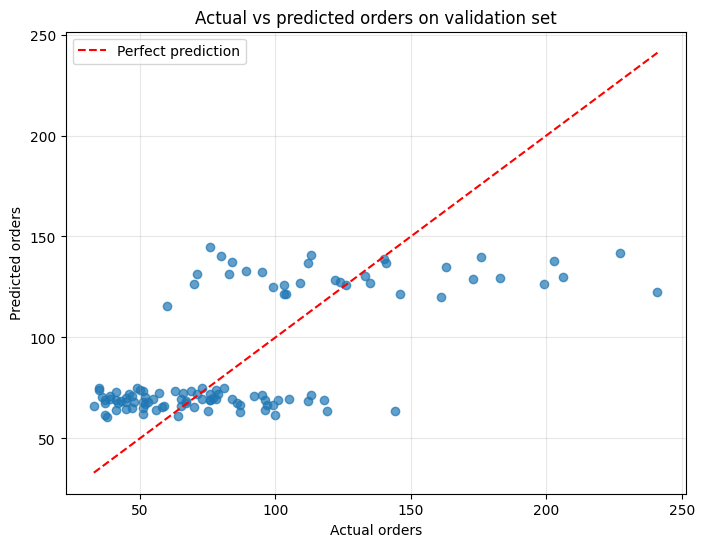

In [199]:
def plot_actual_vs_predicted(
    error_table: pd.DataFrame,
    actual_column: str = "actual_orders",
    predicted_column: str = "predicted_orders",
) -> None:
    """Plot actual versus predicted values."""
    plt.figure(figsize=(8, 6))

    plt.scatter(
        error_table[actual_column],
        error_table[predicted_column],
        alpha=0.7,
    )

    min_value = min(error_table[actual_column].min(), error_table[predicted_column].min())
    max_value = max(error_table[actual_column].max(), error_table[predicted_column].max())

    plt.plot(
        [min_value, max_value],
        [min_value, max_value],
        linestyle="--",
        color="red",
        label="Perfect prediction",
    )

    plt.xlabel("Actual orders")
    plt.ylabel("Predicted orders")
    plt.title("Actual vs predicted orders on validation set")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


plot_actual_vs_predicted(tuned_validation_errors)


## Actual VS predicted interpretation

### The actual VS predicted plot shows that the tuned model captures broad demand levels, but predictions are grouped into bands rather than following the perfect prediction line closely.

### The model tends to underpredict very high-order days and sometimes overpredict lower-order days. This matches the earlier error analysis showing that weekend and high-demand services are more difficult to predict.

### This suggests that the available pre-service features are useful, but they do not fully explain extreme demand days. Additional business features such as reservations, promotions, local events, or menu changes could improve prediction quality.


---

---

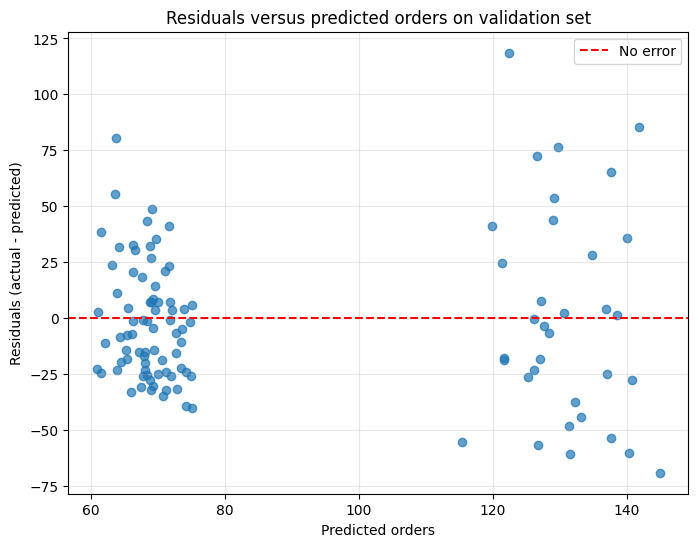

In [200]:
def plot_residuals(
    error_table: pd.DataFrame,
    predicted_column: str = "predicted_orders",
    error_column: str = "error",
) -> None:
    """Plot residuals against predicted values."""
    plt.figure(figsize=(8, 6))

    plt.scatter(
        error_table[predicted_column],
        error_table[error_column],
        alpha=0.7,
    )

    plt.axhline(
        y=0,
        linestyle="--",
        color="red",
        label="No error",
    )

    plt.xlabel("Predicted orders")
    plt.ylabel("Residuals (actual - predicted)")
    plt.title("Residuals versus predicted orders on validation set")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


plot_residuals(tuned_validation_errors)


## Residual plot interpretation

### The residual plot shows that model errors are not completely random. Predictions are concentrated in two main ranges, which suggests the model is separating lower-demand and higher-demand services but still struggles with variation inside those groups.

### Some high-demand services are still underpredicted, while some lower-demand services are overpredicted. This supports the earlier conclusion that the available features do not fully explain unusual demand changes.

### The model is useful as a first version, but future improvements should focus on adding stronger demand signals, especially for weekends and high-variation service periods.


---

---

# Final test evaluation

### After selecting and analyzing the tuned Random Forest model, Now we reach the final step :

# Evaluate it on the untouched test set .

The test set has not been used for model training, validation comparison, hyperparameter tuning, or model diagnostics. 

Wewill apply the same temperature imputation rule learned from the training data on the test features before evaluation.

This final evaluation gives the most honest estimate of how the selected model may perform on new unseen data.


In [201]:
def apply_month_temperature_imputation(
    train_data: pd.DataFrame,
    data_to_transform: pd.DataFrame,
    temperature_column: str = "temperature",
    month_column: str = "month",
) -> pd.DataFrame:
    """Apply month-based temperature imputation using medians learned from training data."""
    transformed_data = data_to_transform.copy()

    monthly_medians = train_data.groupby(month_column)[temperature_column].median()
    global_median = train_data[temperature_column].median()

    month_based_values = transformed_data[month_column].map(monthly_medians)
    fallback_values = month_based_values.fillna(global_median)

    transformed_data[temperature_column] = transformed_data[temperature_column].fillna(fallback_values)

    return transformed_data


X_test_month_temp = apply_month_temperature_imputation(
    train_data=X_train,
    data_to_transform=X_test,
)

tuned_random_forest_test_metrics = evaluate_regression_model(
    model=best_random_forest_model,
    X=X_test_month_temp,
    y_true=y_test,
    dataset_name="tuned_random_forest_test",
)

tuned_random_forest_test_metrics


,dataset,mae,rmse,r2_score
0,tuned_random_forest_test,23.980006,30.003775,0.391628


## Final test results

The tuned Random Forest model achieved a test MAE of about 24 orders and a test RMSE of about 30 orders.

The test MAE is lower than the validation MAE, which suggests that the selected model generalizes reasonably well to unseen data. 

The test R² score shows that the model explains a meaningful portion of the variation in total order volume, although there is still unexplained demand variation.

Overall, the model is a useful first version for predicting expected kitchen order volume from pre-service information. 

Future improvements should focus on adding stronger demand signals such as reservations, promotions, local events, menu changes, or other business context.


----

# Final performance summary

In [202]:
final_model_performance = pd.concat(
    [
        tuned_random_forest_train_metrics,
        tuned_random_forest_validation_metrics,
        tuned_random_forest_test_metrics,
    ],
    ignore_index=True,
)

final_model_performance


,dataset,mae,rmse,r2_score
0,tuned_random_forest_train,23.024132,28.768894,0.552472
1,tuned_random_forest_validation,26.265741,33.752985,0.430287
2,tuned_random_forest_test,23.980006,30.003775,0.391628


## Final model performance summary

The selected tuned Random Forest model shows reasonable generalization across train, validation, and test sets.

The training MAE is about 23 orders, the validation MAE is about 26 orders, and the final test MAE is about 24 orders. 

This suggests that the model is not severely overfitting and can provide useful order-volume predictions on unseen data.

The model does not explain all variation in order volume, which is expected because important demand drivers may be missing from the dataset. 

Future versions could improve performance by adding features such as reservations, promotions, local events, menu changes, or other business context.
